In [3]:
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
from qiskit_ibm_runtime import QiskitRuntimeService
import matplotlib.pyplot as plt
from qiskit.circuit.library import UGate
import numpy as np
from qiskit import transpile
from qiskit_ibm_runtime import SamplerV2 as Sampler

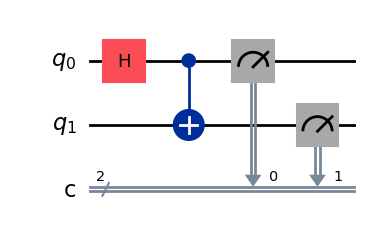

In [2]:
qc = QuantumCircuit(2, 2)

qc.h(0)
qc.cx(0, 1)
qc.measure([0, 1], [0, 1])
qc.draw('mpl')

{'00': 507, '11': 517}


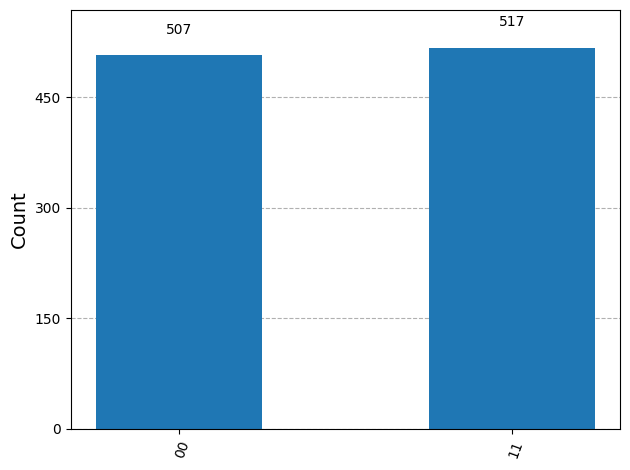

In [3]:
simulator = AerSimulator()
result = simulator.run(qc, shots=1024).result()
counts = result.get_counts()

print(counts)
plot_histogram(counts)

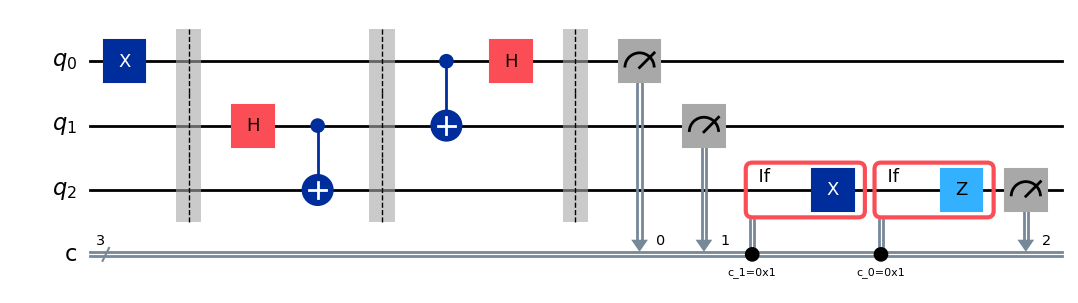

In [5]:
qc = QuantumCircuit(3, 3)

# Set q0 in state |1 (the content to teleport)
qc.x(0)
qc.barrier()

# Create Bell pair between q1 (Alice) and q2 (Bob)
qc.h(1)
qc.cx(1, 2)
qc.barrier()

# Alice's Bell-basis measurement
qc.cx(0, 1)
qc.h(0)
qc.barrier()

# Alice measures her two qubits
qc.measure(0, 0)
qc.measure(1, 1)

# Bob's conditioned corrections
with qc.if_test((1, 1)):
    qc.x(2)
with qc.if_test((0, 1)):
    qc.z(2)

# Measure Bob's qubit
qc.measure(2, 2)

qc.draw('mpl')

{'101': 271, '110': 233, '111': 254, '100': 266}


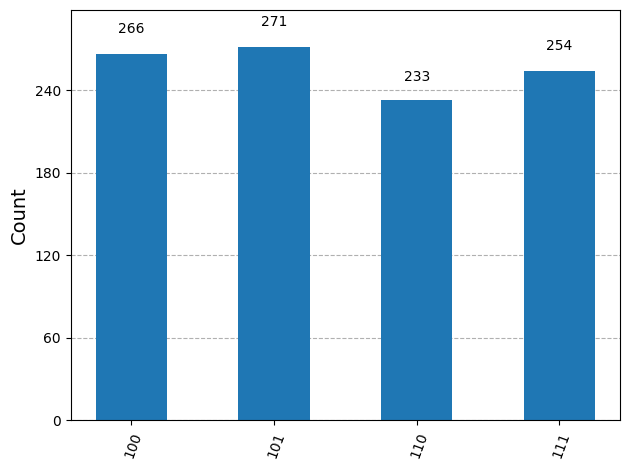

In [6]:
simulator = AerSimulator()
result = simulator.run(qc, shots=1024).result()
counts = result.get_counts()

print(counts)
plot_histogram(counts)

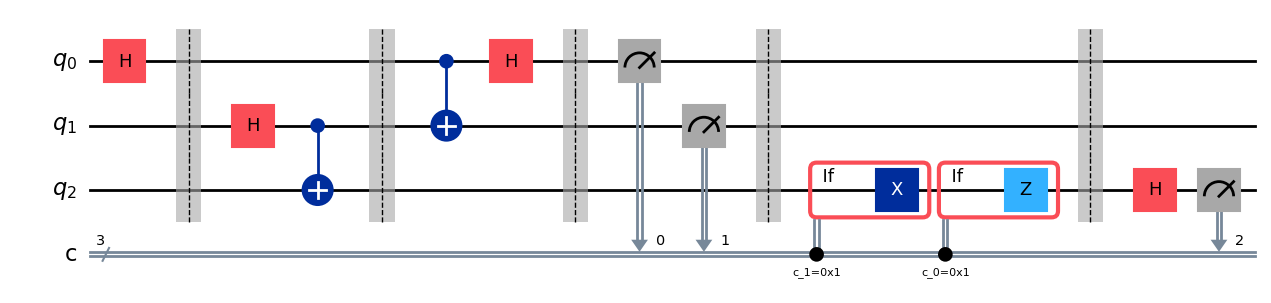

In [7]:
qc = QuantumCircuit(3, 3)

# Set q0 in |+ using H
qc.h(0)
qc.barrier()

# Bell pair between q1 and q2
qc.h(1)
qc.cx(1, 2)
qc.barrier()

# Alice's operations
qc.cx(0, 1)
qc.h(0)
qc.barrier()

# Alice's measurements
qc.measure(0, 0)
qc.measure(1, 1)
qc.barrier()

# Bob's corrections
with qc.if_test((1, 1)):
    qc.x(2)
with qc.if_test((0, 1)):
    qc.z(2)
qc.barrier()

# Verification
qc.h(2)
qc.measure(2, 2)

qc.draw('mpl')

{'000': 273, '011': 253, '001': 262, '010': 236}


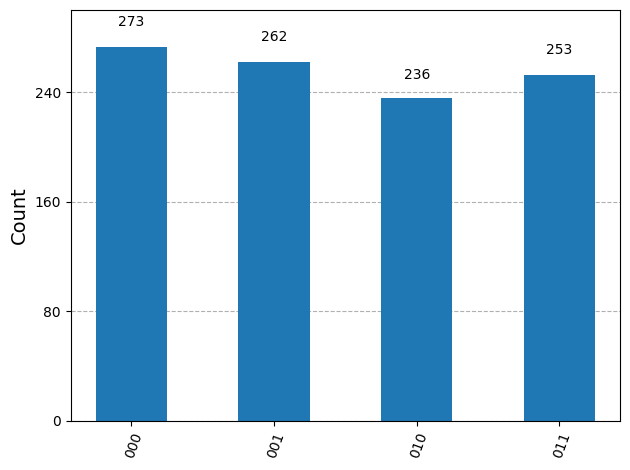

In [8]:
simulator = AerSimulator()
result = simulator.run(qc, shots=1024).result()
counts = result.get_counts()

print(counts)
plot_histogram(counts)

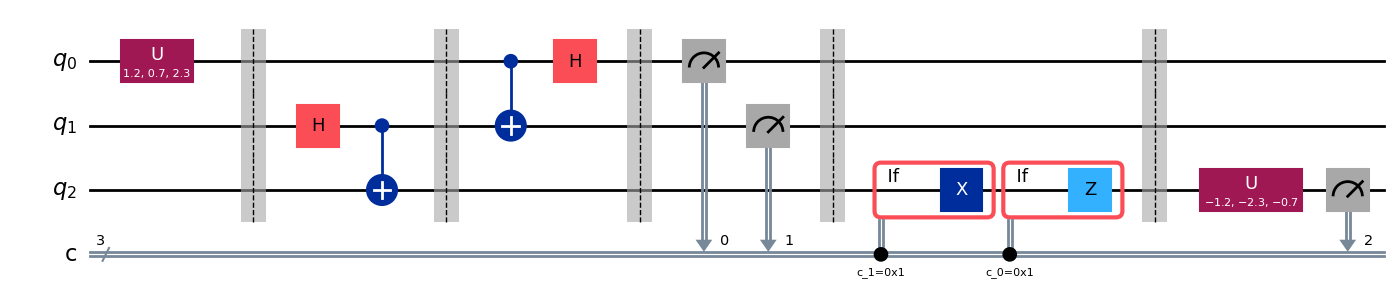

In [6]:
theta, phi, lam = 1.2, 0.7, 2.3
prep_gate = UGate(theta, phi, lam)
inverse_gate = prep_gate.inverse()

qc = QuantumCircuit(3, 3)

# Set q0 in a random arbitrary state
qc.append(prep_gate, [0])
qc.barrier()

# Bell pair
qc.h(1)
qc.cx(1, 2)
qc.barrier()

qc.cx(0, 1)
qc.h(0)
qc.barrier()

# Alice measures
qc.measure(0, 0)
qc.measure(1, 1)
qc.barrier()

# Bob corrects
with qc.if_test((1, 1)):
    qc.x(2)
with qc.if_test((0, 1)):
    qc.z(2)
qc.barrier()

# Verification using U-inverse
qc.append(inverse_gate, [2])
qc.measure(2, 2)

qc.draw('mpl')

{'011': 279, '000': 244, '001': 252, '010': 249}


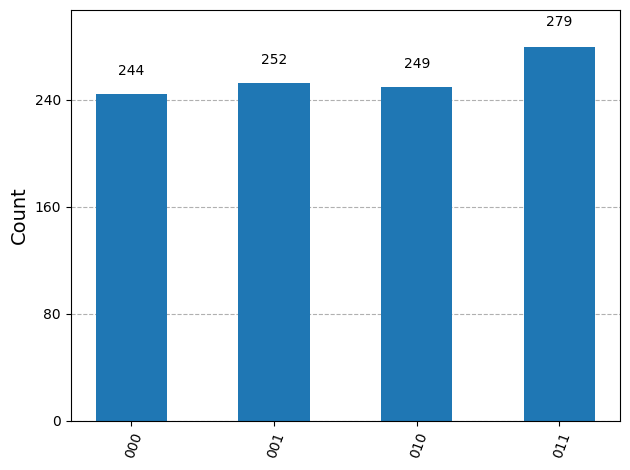

In [7]:
simulator = AerSimulator()
result = simulator.run(qc, shots=1024).result()
counts = result.get_counts()

print(counts)
plot_histogram(counts)

In [13]:
# Credentials. Ignore

# QiskitRuntimeService.save_account(
#     channel="ibm_quantum_platform",
#     token="",
#     overwrite=True
# )

In [2]:
service = QiskitRuntimeService()
backend = service.least_busy(operational=True, simulator=False)
print(f"Running on: {backend.name}")
print(f"Queue length: {backend.status().pending_jobs}")

qiskit_runtime_service.__init__:WARNING:2026-05-07 16:29:32,726: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: open-instance. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().
qiskit_runtime_service.backends:WARNING:2026-05-07 16:29:33,397: Loading instance: open-instance, plan: open
qiskit_runtime_service.backends:WARNING:2026-05-07 16:29:34,958: Using instance: open-instance, plan: open


Running on: ibm_kingston
Queue length: 0


Original depth: 10, transpiled depth: 27


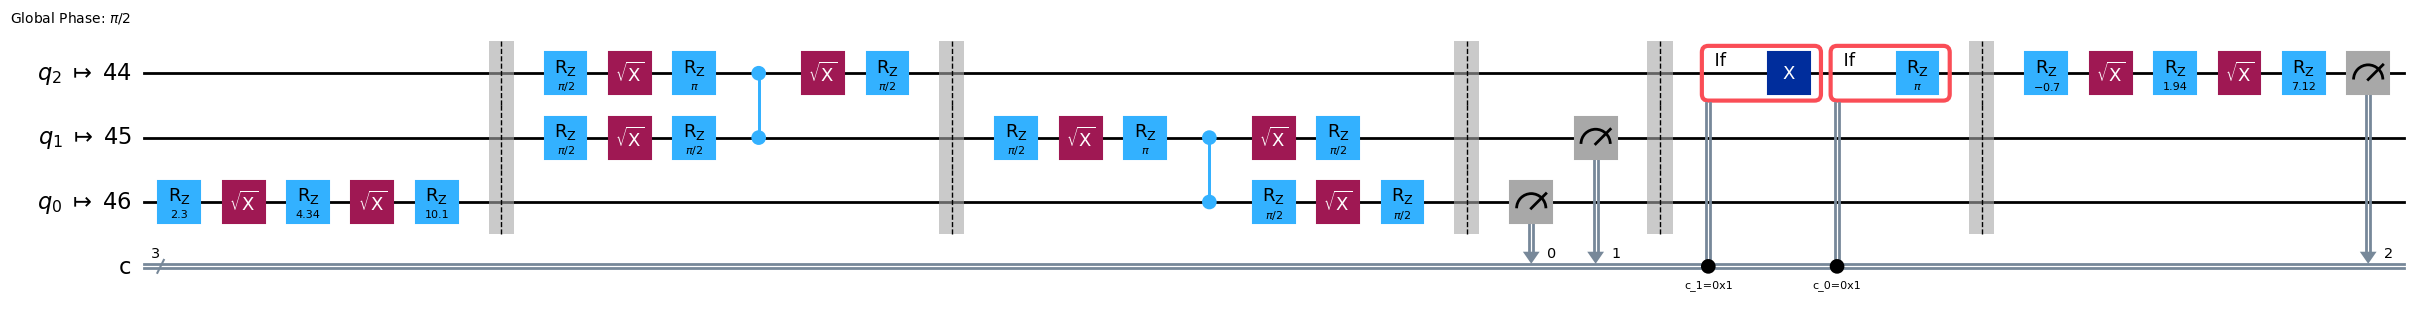

In [8]:
transpiled_qc = transpile(qc, backend=backend, optimization_level=3)
print(f"Original depth: {qc.depth()}, transpiled depth: {transpiled_qc.depth()}")
transpiled_qc.draw('mpl', fold=-1)

In [9]:
sampler = Sampler(mode=backend)
job = sampler.run([transpiled_qc], shots=1024)

print(f"Job ID: {job.job_id()}")
print(f"Status: {job.status()}")

Job ID: d7ui1hrack5s73be8re0
Status: QUEUED


{'011': 220, '000': 244, '010': 266, '001': 225, '111': 24, '100': 18, '110': 16, '101': 11}


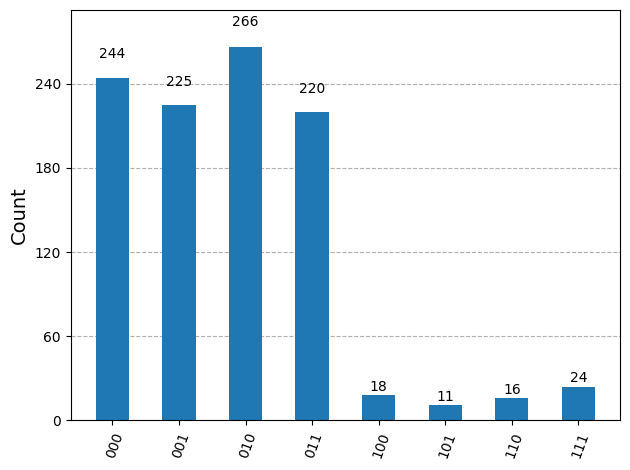

In [10]:
result = job.result()
counts = result[0].data.c.get_counts()

print(counts)
plot_histogram(counts)

In [11]:
total_shots = sum(counts.values())
correct = sum(v for k, v in counts.items() if k.startswith('0'))
fidelity = correct / total_shots
print(f"Teleportation fidelity: {fidelity:.1%}")

Teleportation fidelity: 93.3%
